In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('/content/spread_locator.csv')

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


#1. Fit Bernoulli and Binomial Distribution

In [3]:
df['success_flag'] = df['transaction_status'].apply(lambda x: 1 if x == 'Success' else 0)

p = df['success_flag'].mean()
print("Probability of Success:", p)

Probability of Success: 0.44545454545454544


In [6]:
weekly = df.resample('W', on='transaction_date')['success_flag'].sum()

n = 7
binom = stats.binom(n, p)

print("Mean weekly success:", weekly.mean())

Mean weekly success: 16.333333333333332


#2. Fit Poisson Distribution

Lambda (mean): 7.096774193548387


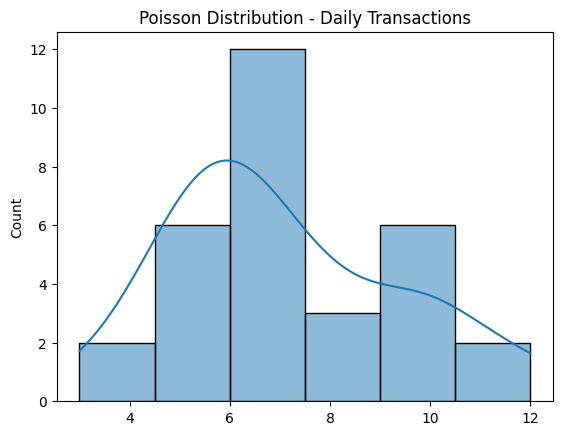

In [8]:
daily_counts = df.groupby('transaction_date').size()

lambda_ = daily_counts.mean()
print("Lambda (mean):", lambda_)

sns.histplot(daily_counts, kde=True)
plt.title("Poisson Distribution - Daily Transactions")
plt.show()

#3. Log-Normal & Power Law (Transaction Amount)

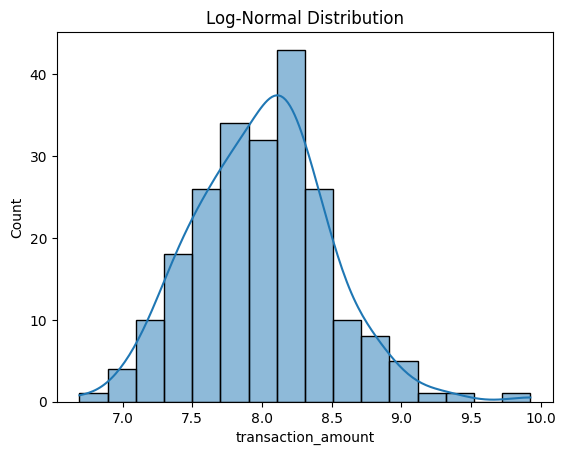

In [9]:
amounts = df['transaction_amount']

log_amounts = np.log(amounts)

sns.histplot(log_amounts, kde=True)
plt.title("Log-Normal Distribution")
plt.show()

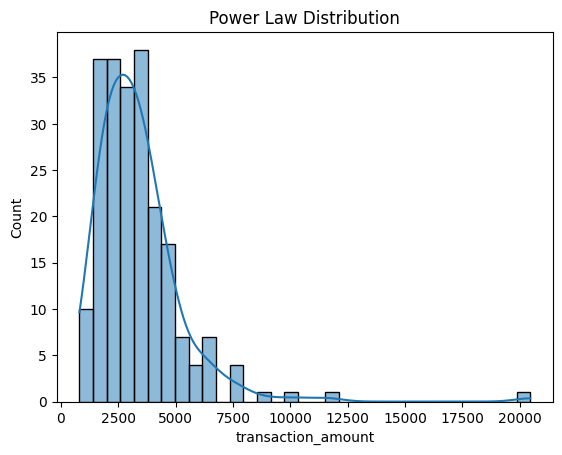

In [10]:
sns.histplot(amounts, kde=True)
plt.title("Power Law Distribution")
plt.show()

#4. Generate Q-Q Plot

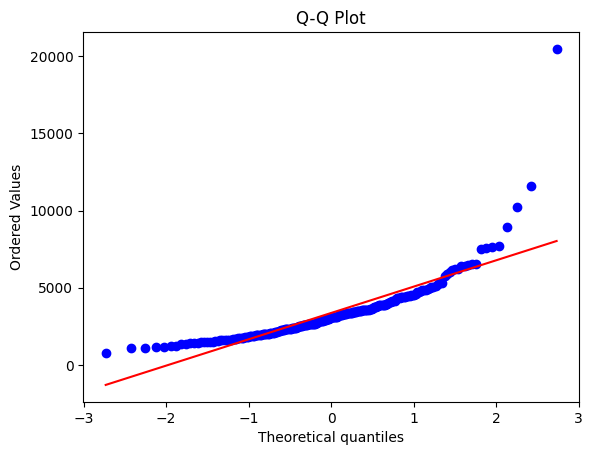

In [11]:
stats.probplot(amounts, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

If points deviate from line → data is not normal

Transaction data is usually right-skewed

#5. Apply Box-Cox Transform

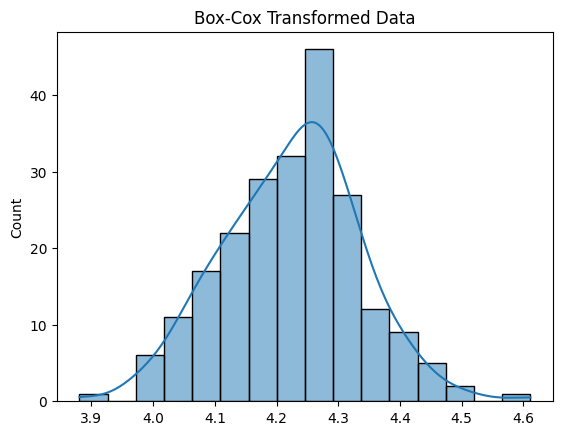

In [12]:
boxcox_data, _ = stats.boxcox(amounts)

sns.histplot(boxcox_data, kde=True)
plt.title("Box-Cox Transformed Data")
plt.show()

#6. Calculate Z-Scores & Probability > ₹5000

In [13]:
mean = amounts.mean()
std = amounts.std()

df['z_score'] = (amounts - mean) / std

prob = 1 - stats.norm.cdf(5000, mean, std)

print("Probability > 5000:", prob)

Probability > 5000: 0.20517209567554384


#7. Plot PDF and CDF

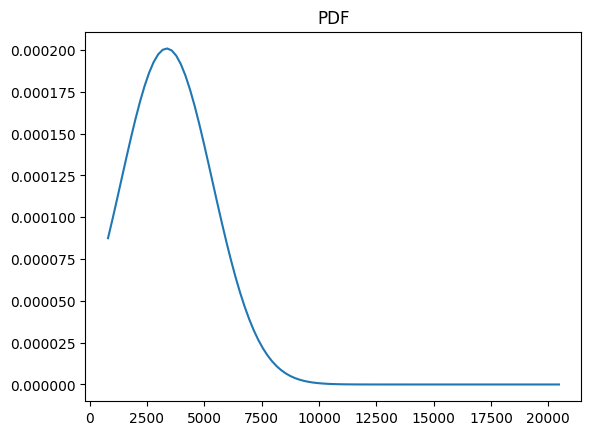

In [15]:
x = np.linspace(min(amounts), max(amounts), 100)

pdf = stats.norm.pdf(x, mean, std)
cdf = stats.norm.cdf(x, mean, std)

plt.plot(x, pdf)
plt.title("PDF")
plt.show()

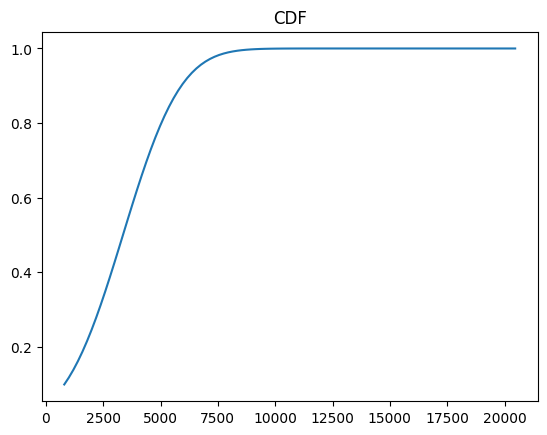

In [16]:
plt.plot(x, cdf)
plt.title("CDF")
plt.show()